### 1. Install Dependencies

In [1]:
!pip install torch torchvision Pillow matplotlib
!pip install pycocotools

### 2. Verify Installation

In [2]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

PyTorch: 2.10.0+cu128
CUDA: True


### 3. Download the Dataset

In [3]:
import os
import urllib.request
import zipfile

# Download the dataset
url = ('https://www.cis.upenn.edu/~jshi/ped_html/'
       'PennFudanPed.zip')
zip_path = 'PennFudanPed.zip'

if not os.path.exists('PennFudanPed'):
    print('Downloading dataset...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    os.remove(zip_path)
    print('Done!')
else:
    print('Dataset already exists.')

Done!


### 4. Explore the Data

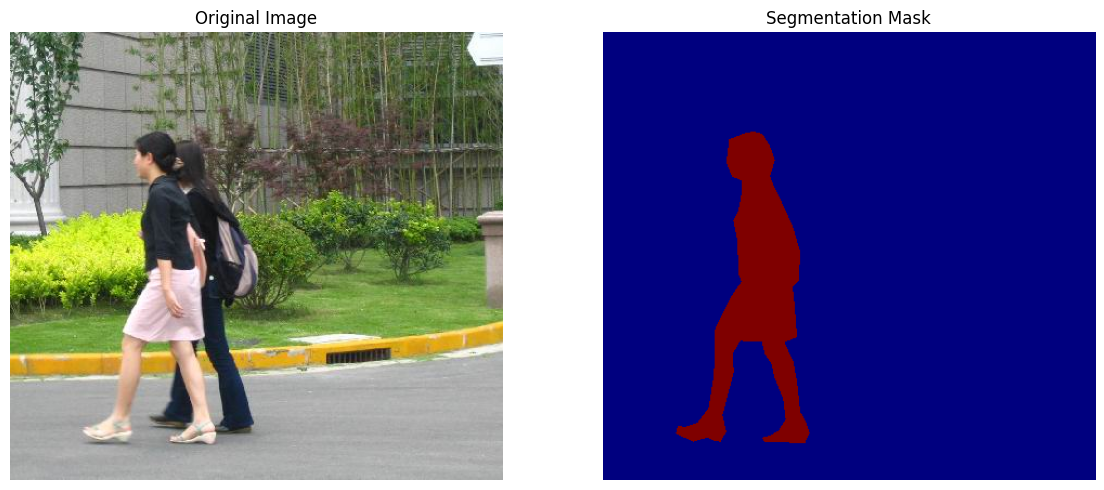

Mask values: [0 1]
0 = background, 1,2,3... person IDs


In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load a sample image and its mask
img = Image.open('PennFudanPed/PNGImages/FudanPed00002.png')
mask = Image.open('PennFudanPed/PedMasks/FudanPed00002_mask.png')

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[1].imshow(np.array(mask), cmap='jet')
axes[1].set_title('Segmentation Mask')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Check unique values in the mask
mask_arr = np.array(mask)
print(f'Mask values: {np.unique(mask_arr)}')
print('0 = background, 1,2,3... person IDs')

### 5. Build the Dataset Class

In [5]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

class PennFudanDataset(Dataset):
    """Penn-Fudan Pedestrian Detection Dataset.
    Loads images and extracts bounding boxes
    from segmentation masks automatically."""

    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        # List all images, sorted for consistency
        self.imgs = sorted(os.listdir(os.path.join(root, 'PNGImages')))
        self.masks = sorted(os.listdir(os.path.join(root, 'PedMasks')))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.root, 'PNGImages', self.imgs[idx])
        image = Image.open(img_path).convert('RGB')

        # Load mask
        mask_path = os.path.join(self.root, 'PedMasks', self.masks[idx])
        mask = np.array(Image.open(mask_path), dtype=np.int32)

        # Each unique nonzero value = one person
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[obj_ids != 0] # remove bg

        # Extract bounding box for each person
        boxes = []
        for obj_id in obj_ids:
            pos = np.where(mask == obj_id)
            ymin = float(np.min(pos[0]))
            ymax = float(np.max(pos[0]))
            xmin = float(np.min(pos[1]))
            xmax = float(np.max(pos[1]))

            # Skip degenerate boxes
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])

        num_objs = len(boxes)

        # Convert everything to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        # All objects are class 1 (pedestrian)
        labels = torch.ones((num_objs,), dtype=torch.int64)
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, target

### 6. Test the Dataset

In [6]:
dataset = PennFudanDataset('PennFudanPed')
print(f'Dataset size: {len(dataset)} images')

# Inspect first sample
img, target = dataset[0]
print(f'Image shape: {img.shape}')
print(f'Num people: {len(target["boxes"])}')
print(f'Boxes: \n {target["boxes"]}')

Dataset size: 170 images
Image shape: torch.Size([3, 536, 559])
Num people: 2
Boxes: 
 tensor([[159., 181., 301., 430.],
        [419., 170., 534., 485.]])


### 7. Create Data Loaders

In [7]:
from torch.utils.data import DataLoader

# Create full dataset
dataset = PennFudanDataset('PennFudanPed')

# Split into train and test
torch.manual_seed(42)
total = len(dataset)
train_size = 140
test_size = total - train_size # reproducible split

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

print(f'Train: {len(train_dataset)} images')
print(f'Test: {len(test_dataset)} images')

# Custom collate (required for detection)
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

Train: 140 images
Test: 30 images


### 8. Modify the Model

In [8]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    # Load COCO pre-trained model
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights)

    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# 2 classes: background + pedestrian
NUM_CLASSES = 2
model = get_model(NUM_CLASSES)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f'Model on: {device}')
print(f'Classes: {NUM_CLASSES}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 187MB/s]


Model on: cuda
Classes: 2


### 9. Configure Optimizer & Train the Model

In [9]:
# [Task 5] Freeze the backbone before creating the optimizer
for p in model.backbone.parameters():
    p.requires_grad = False

# Trainable parameters only (this will now naturally exclude the frozen backbone)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005,
)

# Reduce LR by 10x after epoch 5
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

import time

NUM_EPOCHS = 2

for epoch in range(NUM_EPOCHS):
    model.train()
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Calculate loss
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} loss: {loss.item():.4f}')

print('Training complete!')

Epoch 1/2 loss: 0.1866
Epoch 2/2 loss: 0.1479
Training complete!


### 10. Save and Load the Model

In [10]:
# Save
save_path = 'pedestrian_detector.pth'
torch.save(model.state_dict(), save_path)
print(f'Saved to {save_path}')

# Load later
def load_model(path, num_classes, device):
    model = get_model(num_classes)
    model.load_state_dict(
        torch.load(path, map_location=device, weights_only=True)
    )
    model.to(device)
    model.eval()
    return model

model = load_model(save_path, NUM_CLASSES, device)
print('Model reloaded!')

Saved to pedestrian_detector.pth
Model reloaded!


### 11. Test on Unseen Images

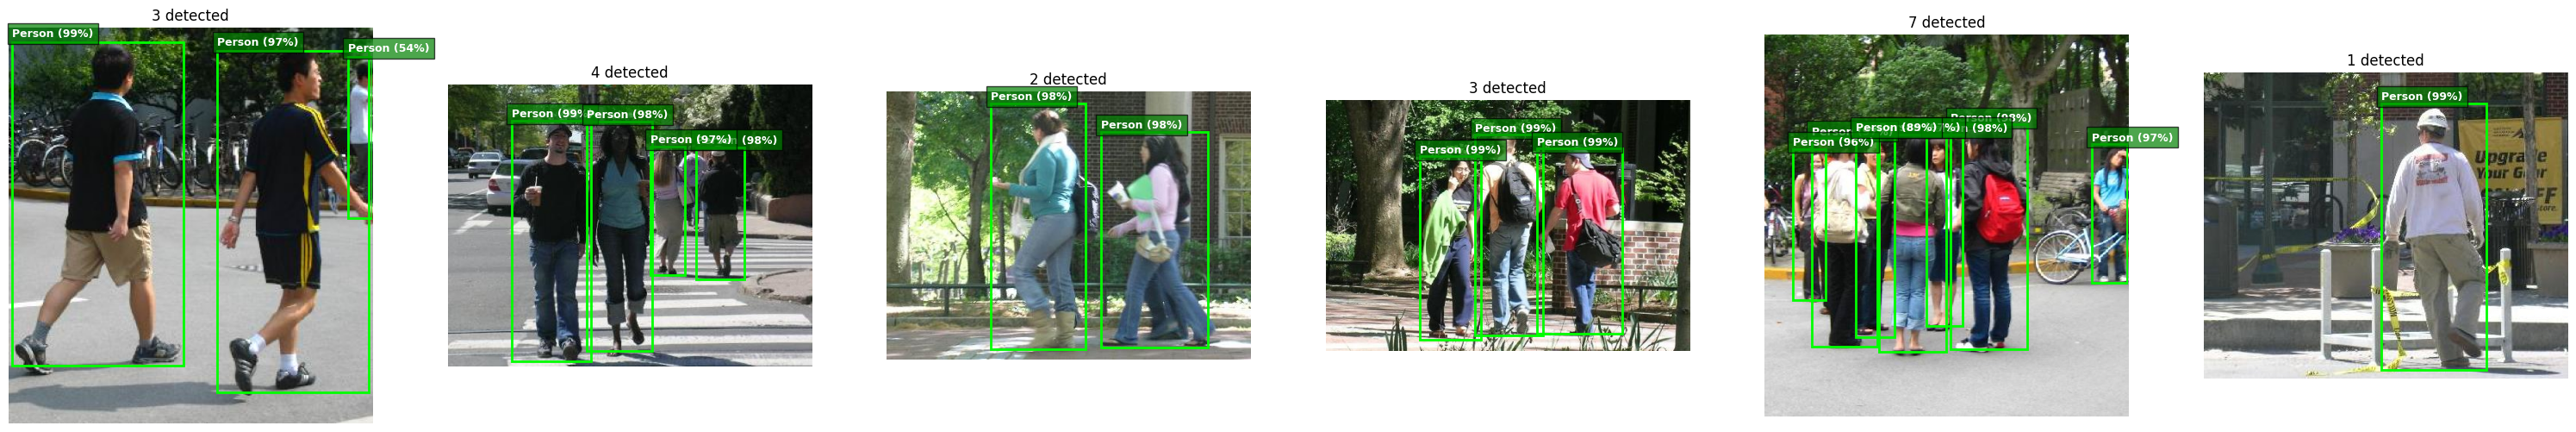

Results saved to test_results.jpg


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms

def test_and_visualize(model, dataset, device, num_images=6, threshold=0.5):
    model.eval()
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))

    for i in range(num_images):
        img_tensor, target = dataset[i]
        with torch.no_grad():
            pred = model([img_tensor.to(device)])[0]

        # Filter by threshold
        mask = pred['scores'] > threshold
        boxes = pred['boxes'][mask].cpu()
        scores = pred['scores'][mask].cpu()

        # Convert tensor to displayable image
        img_np = img_tensor.permute(1, 2, 0).numpy()

        ax = axes[i] if num_images > 1 else axes
        ax.imshow(img_np)

        for j in range(len(boxes)):
            x1, y1, x2, y2 = boxes[j].tolist()
            score = scores[j].item()
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2,
                edgecolor='lime',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-5,
                    f'Person ({score:.0%})',
                    color='white', fontsize=9,
                    fontweight='bold',
                    bbox=dict(facecolor='green', alpha=0.7))

        ax.set_title(f'{len(boxes)} detected')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('test_results.jpg', dpi=150)
    plt.show()
    print('Results saved to test_results.jpg')

# Run on test set
test_and_visualize(model, test_dataset, device)

### 12. Evaluate with Metrics

In [12]:
def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()
    correct, predicted, actual = 0, 0, 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        with torch.no_grad():
            preds = model(images)

        for pred, target in zip(preds, targets):
            pred_boxes = pred['boxes'][pred['scores'] > threshold].cpu()
            gt_boxes = target['boxes']

            predicted += len(pred_boxes)
            actual += len(gt_boxes)

            for pb in pred_boxes:
                for gb in gt_boxes:
                    # IOU
                    x1 = max(pb[0], gb[0])
                    y1 = max(pb[1], gb[1])
                    x2 = min(pb[2], gb[2])
                    y2 = min(pb[3], gb[3])

                    inter = max(0, x2-x1) * max(0, y2-y1)
                    union = (pb[2]-pb[0])*(pb[3]-pb[1]) + (gb[2]-gb[0])*(gb[3]-gb[1]) - inter

                    if inter / union > 0.5:
                        correct += 1
                        break

    precision = correct / max(predicted, 1) if predicted > 0 else 0
    recall = correct / max(actual, 1) if actual > 0 else 0
    f1 = 2 * precision * recall / max(precision + recall, 1e-6)

    print(f'Threshold {threshold}: Precision: {precision:.1%} Recall: {recall:.1%} F1: {f1:.1%}')
    return precision, recall

# Run evaluation
print('\nEvaluation Results')
evaluate_model(model, test_loader, device)


Evaluation Results
Threshold 0.5: Precision: 76.8% Recall: 98.4% F1: 86.3%


(0.7682926829268293, 0.984375)

### 13. Lab Task Solutions

**Task 2: Threshold Tuning & Precision-Recall Curve**


Threshold Tuning:
Threshold 0.3: Precision: 68.8% Recall: 100.0% F1: 81.5%
Threshold 0.5: Precision: 76.8% Recall: 98.4% F1: 86.3%
Threshold 0.7: Precision: 80.8% Recall: 98.4% F1: 88.7%
Threshold 0.9: Precision: 91.2% Recall: 96.9% F1: 93.9%


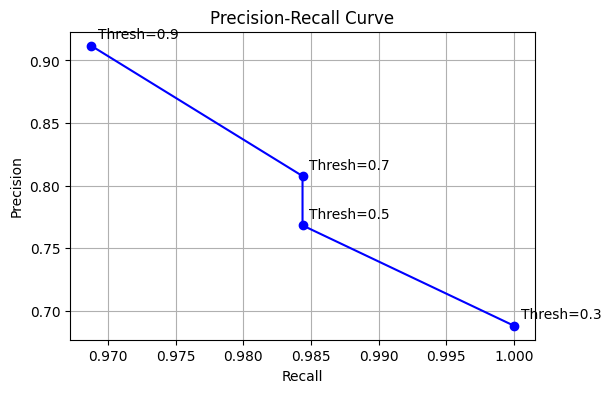

In [13]:
thresholds = [0.3, 0.5, 0.7, 0.9]
precisions = []
recalls = []

print('\nThreshold Tuning:')
for t in thresholds:
    p, r = evaluate_model(model, test_loader, device, threshold=t)
    precisions.append(p)
    recalls.append(r)

# Plotting the curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, marker='o', linestyle='-', color='b')
for i, txt in enumerate(thresholds):
    plt.annotate(f'Thresh={txt}', (recalls[i], precisions[i]), textcoords="offset points", xytext=(5,5))
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

**Task 3: Train for more epochs**

In [14]:
# To train for more epochs, simply adjust the constant in Section 9:
NUM_EPOCHS = 15 # or 20

**Task 4: Smaller training set**

In [15]:
# To test on a smaller training set, modify Section 7 (Create Data Loaders) like this:
torch.manual_seed(42)
total = len(dataset)
train_size = 50 # Or 80
test_size = 30 # Keep the test set the same size for a fair comparison
unused_size = total - train_size - test_size

train_dataset, test_dataset, _ = torch.utils.data.random_split(
    dataset, [train_size, test_size, unused_size]
)

**Task 6: Batch size experiment**

In [16]:
# To experiment with batch sizes, modify the DataLoader in Section 7:
experiment_batch_size = 8 # Try 1, 2, 4, and 8

train_loader = DataLoader(
    train_dataset,
    batch_size=experiment_batch_size,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

**Task 7: Try a lighter model**

In [17]:
# To use MobileNetV3 instead of ResNet50, replace the get_model function in Section 8:
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, FasterRCNN_MobileNet_V3_Large_FPN_Weights

def get_mobilenet_model(num_classes):
    # Load MobileNet pre-trained model
    weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
    model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)

    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = get_mobilenet_model(NUM_CLASSES)
model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 115MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block):